In [16]:

import os
%load_ext autoreload
%autoreload 2
from pathlib import Path
from acados_template import AcadosOcp
from commom_utils.ode_system import ODESystem, check_system_ok, MHESyntheticDataGenerator
import numpy as np
import matplotlib.pyplot as plt

from commom_utils.systems import *
from mhe.mhe_base_model_interface import MheModel, MheCogeGenerator
from mhe.params import MheParams
from mhe.mhe_utils import MheEstimationData, run_mhe_estimation, plot_mhe_results

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import numpy as np
from mhe.params import MheParams

# Общие параметры
mhe_horizont = 300
ts = 0.02


def harmonic(t):
    u  = np.cos(0.3*t)*np.sin(0.1*t + np.pi/2)
    # if(t < 15):
    #     u = 0
    return [u]

def get_input_signals_bycicle(t):
    import math
    w = 0.7
    steering = 0.8 * math.cos(t * 0.25 * w) * math.sin(w * t)
    if t < 25:
        steering = 0
    v = 10.0
    return [v, steering]

# Словарь конфигураций
configs = {
    "MassSpringDamper": {
        "system_class": MassSpringDamper,
        "system_args": [],  # аргументы конструктора (если есть)
        "c0": np.array([1.0, 10.0]),
        "theta_true": np.array([3, 1.0]),
        "measurements_residual_r": np.diag([1, 1]),
        "state_prior_q0": np.diag([1, 1]),
        "noise_peanlty_w": np.eye(2) * 1e3,
        "fim_scaler": 0.2,
        "bounds_noise": [[-0.01, 0.01]] * 2,
        "bounds_state": [[-np.inf, np.inf]] * 2,
        "bounds_param": [[-2000, 2000]] * 2,
    },
    "KinematicBycicle": {
        "system_class": KinematicBycicle,
        "get_input_signals": lambda t: get_input_signals_bycicle(t),
        "get_initial_state": lambda y_meas, u, theta: y_meas[0:1],
        "system_args": [2.65],  # wheelbase
        "c0": np.array([0]),
        "theta_true": np.array([0.05, np.deg2rad(-5.0)]),
        "measurements_residual_r": np.diag([1, 1]),
        "state_prior_q0": np.diag([1]),
        "noise_peanlty_w": np.eye(1) * 1e3,
        "fim_scaler": 0.2,
        "bounds_noise": [[-0.01, 0.01]],
        "bounds_state": [[-np.inf, np.inf]],
        "bounds_param": [np.deg2rad([-5, 5]), [-1, 1]],
    },
    "Integrator": {
        "system_class": Integrator,
        "system_args": [],
        "c0": np.array([0.0, 0.0]),
        "theta_true": np.array([1.0]),
        "measurements_residual_r": np.diag([1]),
        "state_prior_q0": np.diag([1, 1]),
        "noise_peanlty_w": np.eye(2) * 1e3,
        "fim_scaler": 0.2,
        "bounds_noise": [[-0.01, 0.01]] * 2,
        "bounds_state": [[-1e5, 1e5]] * 2,
        "bounds_param": [[0, 20]],
    },
    "DelaySystem": {
        "system_class": DelaySystem,
        "get_input_signals": lambda t: harmonic(t),
        "get_initial_state": lambda y_meas, u, theta: np.hstack((u, 0)),
        "system_args": [2],  # порядок (1 = Паде 1‑го порядка)
        "c0": np.array(2*[0.0]),  # начальное состояние для одного состояния
        "theta_true": np.array([0.4]),
        "measurements_residual_r": np.diag([1]),
        "state_prior_q0": 0*np.diag(2*[1]),
        "noise_peanlty_w": np.eye(2) * 1e3,
        "fim_scaler": 0.1,
        "bounds_noise": 2*[[-0.01, 0.01]],
        "bounds_state": 2*[[-1e5, 1e5]],
        "bounds_param": [[0, 20]],
    },

    "OffsetEstimator": {
        "system_class": OffsetEstimator,
        "get_input_signals": lambda t: get_input_signals_bycicle(t),
        "system_args": [2.65, 1], 
        "c0": np.array(1*[0.0]),  # начальное состояние для одного состояния
        "theta_true": np.array([0.4]),
        "measurements_residual_r": np.diag([1]),
        "state_prior_q0": 0*np.diag(1*[1]),
        "noise_peanlty_w": np.eye(1) * 1e3,
        "fim_scaler": 0.1,
        "bounds_noise": 1*[[-0.01, 0.01]],
        "bounds_state": 1*[[-1e5, 1e5]],
        "bounds_param": [[0, 20]],
    }

}

# Выбор модели (измените ключ)
model_key = "KinematicBycicle"   # например, "MassSpringDamper", "KinematicBycicle", "Integrator"
cfg = configs[model_key]


class CustomSystem(cfg["system_class"]):
    def get_initial_state(self, y_meas, u, theta):
        return y_meas
    
if "get_initial_state" in cfg:
    def get_initial_state(self, y_meas, u, theta):
        return cfg["get_initial_state"](y_meas, u, theta)
    CustomSystem.get_initial_state = get_initial_state
else:
    def get_initial_state(self, y_meas, u, theta):
        return y_meas
    CustomSystem.get_initial_state = get_initial_state 

if "get_input_signals" in cfg:
    def get_input_signals(self, t):
        return cfg["get_input_signals"](t)
    CustomSystem.get_input_signals = get_input_signals
# Создаём систему
system = CustomSystem(*cfg["system_args"])

# Параметры MHE
mhe_params = MheParams(
    dt=ts,
    mhe_horizont=mhe_horizont,
    state_prior_q0=cfg["state_prior_q0"],
    noise_peanlty_w=cfg["noise_peanlty_w"],
    measurements_residual_r=cfg["measurements_residual_r"],
    bounds_noise=cfg["bounds_noise"],
    bounds_state=cfg["bounds_state"],
    bounds_param=cfg["bounds_param"],
    fim_scaler=cfg["fim_scaler"]
)

mhe_params.print()

dt: 0.02
mhe_horizont: 300
state_prior_q0: [[1]]
noise_peanlty_w: [[1000.]]
measurements_residual_r: [[1 0]
 [0 1]]
bounds_param: [array([-0.08726646,  0.08726646]), [-1, 1]]
bounds_state: [[-inf, inf]]
bounds_noise: [[-0.01, 0.01]]
fim_scaler: 0.2


In [3]:
cfg["get_input_signals"](0)

[10.0, 0]

In [4]:
cfg["get_input_signals"](0)

[10.0, 0]

In [5]:
# system = KinematicBycicle(2)
# cfg["get_input_signals"](t)

In [6]:
class MyCogeGenerator(MheCogeGenerator):
    def __init__(self):
        super().__init__(system, mhe_params,  Path(os.getcwd())/'mhe/tmp_generated', 'kinematik_mhe')

    def modify_ocp_problem(self, ocp_mhe: AcadosOcp) -> AcadosOcp:
        ocp_mhe.solver_options.print_level = 1
        ocp_mhe.solver_options.nlp_solver_stats_level = 2

        # ocp_mhe.solver_options.integrator_type = 'IRK'
        # ocp_mhe.solver_options.sim_method_num_stages = 3
        # ocp_mhe.solver_options.sim_method_newton_tol = 1e-9
        # ocp_mhe.solver_options.sim_method_newton_iter = 10

        # # В настройках решателя
        # ocp_mhe.solver_options.nlp_solver_type = 'SQP'
        # ocp_mhe.solver_options.nlp_solver_max_iter = 200
        # ocp_mhe.solver_options.levenberg_marquardt = 1e-6
        # ocp_mhe.solver_options.globalization = 'FIXED_STEP'
        # ocp_mhe.solver_options.globalization_fixed_step_length = 0.9
        # ocp_mhe.solver_options.nlp_solver_tol_stat = 1e-4   # временно ослабить
        # ocp_mhe.solver_options.nlp_solver_tol_eq = 1e-4
        # ocp_mhe.solver_options.nlp_solver_tol_ineq = 1e-4
        # ocp_mhe.solver_options.nlp_solver_tol_comp = 1e-4

        # ocp_mhe.solver_options.nlp_solver_max_iter =120
        # #ocp_mhe.solver_options.nlp_solver_tol_stat = 1e-3
        # ocp_mhe.solver_options.nlp_solver_type = 'SQP'
        # ocp_mhe.solver_options.nlp_solver_max_iter = 200
        # ocp_mhe.solver_options.nlp_solver_tol_stat = 1e-4
        # ocp_mhe.solver_options.nlp_solver_tol_eq = 1e-4
        # ocp_mhe.solver_options.nlp_solver_tol_ineq = 1e-4
        # ocp_mhe.solver_options.nlp_solver_tol_comp = 1e-4
        # ocp_mhe.solver_options.hessian_approx = 'GAUSS_NEWTON'
        # ocp_mhe.solver_options.globalization = 'FIXED_STEP'
        # ocp_mhe.solver_options.globalization_fixed_step_length = 0.9
        # ocp_mhe.solver_options.levenberg_marquardt = 1e-6
        # ocp_mhe.solver_options.qp_solver = 'PARTIAL_CONDENSING_HPIPM'
        # ocp_mhe.solver_options.hpipm_options = {
        #     'scale': 1,
        #     'scale_ux': 1,
        #     'iter_max': 1000,
        #     'tol': 1e-6,
        #     'reg_epsilon': 1e-6,
        #     'reg_epsilon_s': 1e-6,
        # }
        return ocp_mhe

generator = MyCogeGenerator()

#assert check_system_ok(system) == True

acados_solver_mhe = generator.generate_code()

Please export ACADOS_SOURCE_DIR to avoid this warning.
[-0.08726646 -1.        ]
[0.08726646 1.        ]
[1 2]
kinematik_mhe
2 1

got cost_type EXTERNAL for cost_type_0, cost_type, cost_type_e, hessian_approx: 'GAUSS_NEWTON'.
With this setting, acados will proceed computing the exact Hessian for the cost term and no Hessian contribution from constraints and dynamics.
If the external cost is a linear least squares cost, this coincides with the Gauss-Newton Hessian.
Note: There is also the option to use the external cost module with a numerical Hessian approximation (see `ext_cost_num_hess`).
OR the option to provide a symbolic custom Hessian approximation (see `cost_expr_ext_cost_custom_hess`).


got cost_type EXTERNAL for cost_type_0, cost_type, cost_type_e, hessian_approx: 'GAUSS_NEWTON'.
With this setting, acados will proceed computing the exact Hessian for the cost term and no Hessian contribution from constraints and dynamics.
If the external cost is a linear least squares cost, th

In [7]:
# Create the generator

simulation_system = system# KinematicBycicleActuator(wheelbase=2.65, kp = 200, kv = 10)


# Начальное состояние (c0)
c0 = cfg["c0"]

# Истинные параметры 
theta_true = cfg["theta_true"]

theta_true = theta_true
data_gen = MHESyntheticDataGenerator(simulation_system, sigma=0.0)

# Parameters
t0 = 0
T_f = mhe_params.dt * mhe_params.mhe_horizont          
N_measurement = mhe_params.mhe_horizont           
overlap_points = 1#int(N_measurement*0.5)
num_windows = 10                                    # number of overlapping windows


# Generate exact windows
t_windows, u_windows, meas_windows, full_windows = data_gen.generate_sliding_windows_exact(
    c0, theta_true, t0, T_f, num_windows, N_measurement + 1, overlap_points=overlap_points
)

# Check the time span of the first window
print(f"Window 0: start={t_windows[0][0]:.6f}, end={t_windows[0][-1]:.6f}, span={t_windows[0][-1]-t_windows[0][0]:.6f}")
# This should equal T_f
def get_window(i):
    return t_windows[i], u_windows[i][:], meas_windows[i], full_windows[i]

INFO:2026-04-29 10:47:34,442:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-04-29 10:47:34,442 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


Window 0: start=0.000000, end=6.000000, span=6.000000


In [8]:
mhe_model=generator.get_model()

In [9]:
def make_system_trajectory(mhe_model: MheModel, 
               simU: np.array, 
               initial_x0: np.array, 
               initial_theta: np.array, 
               N: int) -> tuple :
    assert(len(initial_x0) == mhe_model.state_length)
    assert(len(initial_theta) == mhe_model.param_length)
    assert simU.shape[0] >= N, f"simU должен содержать хотя бы {N} строк"

    x_sim = initial_x0.copy()
    trajectory = np.zeros((N + 1, mhe_model.state_length))
    integrate_f = mhe_model.create_intefrate_function(0.02, "integrate")
    trajectory[0] = x_sim
    for j in range(N):
        # Формируем расширенный вектор состояния + параметров
        x_aug = np.hstack((x_sim, initial_theta))
        acados_solver_mhe.set(j, "x", x_aug)

        # Делаем шаг вперёд по дискретной динамике
        if j < N - 1:
            x_sim = np.array(integrate_f(x_sim, initial_theta, simU[j, :])).T[0]
        trajectory[j + 1] = x_sim
    return trajectory


/tmp/ipykernel_512256/2391174536.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


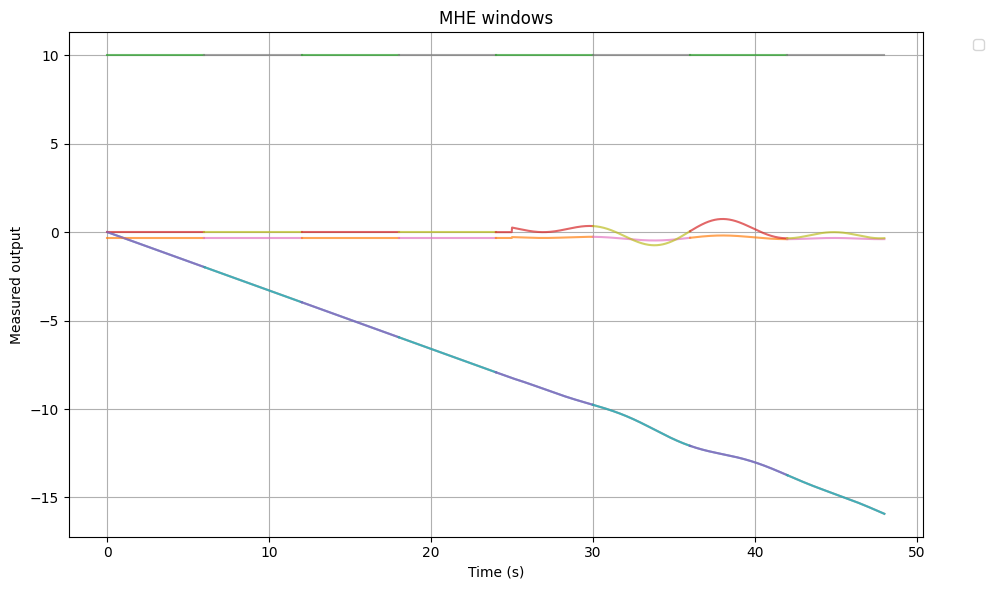

In [10]:
plt.figure(figsize=(10, 6))
for i in range(0, 8):
    t, simU, simY, sim_full_state = get_window(i)

    plt.plot(t, simY[:, :3], alpha=0.7)
    plt.plot(t, simU[:, :3], alpha=0.7)
    

    x0 = system.get_initial_state(simY[0], simU[0], theta_true)
    
    # sim_full_state_ode_integrate = make_system_trajectory(generator.get_model(), 
    #              simU,
    #              x0,
    #              theta_true,
    #              N_measurement
    #              )
    plt.plot(t, sim_full_state[:, :3], alpha=0.7)
    # plt.plot(t, sim_full_state_ode_integrate[:, :3], alpha=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Measured output')
plt.title('MHE windows')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
from acados_template import AcadosOcp, AcadosOcpSolver

def reset_mhe_solver(mhe_model: MheModel, 
               acados_solver_mhe: AcadosOcpSolver, 
               simU: np.array, 
               initial_x0: np.array, 
               initial_theta: np.array, 
               N: int) -> tuple :
    assert(len(initial_x0) == mhe_model.state_length)
    assert(len(initial_theta) == mhe_model.param_length)
    assert simU.shape[0] >= N, f"simU должен содержать хотя бы {N} строк"

    x_sim = initial_x0.copy()

    integrate_f = mhe_model.create_intefrate_function(0.02, "integrate")
    for j in range(N):
        # Формируем расширенный вектор состояния + параметров
        x_aug = np.hstack((x_sim, initial_theta))
        acados_solver_mhe.set(j, "x", x_aug)

        # Делаем шаг вперёд по дискретной динамике
        # if j < N - 1:
        #     x_sim = np.array(integrate_f(x_sim, initial_theta, simU[j, :])).T[0]





In [12]:
system.get_initial_state(simY[0], simU[0], initial_theta)

NameError: name 'initial_theta' is not defined

In [17]:
theta_true

array([ 0.05      , -0.08726646])

In [13]:
initial_theta = theta_true*0.5
reset_mhe_solver(generator.get_model(), 
                 acados_solver_mhe,
                 simU,
                 system.get_initial_state(simY[0], simU[0], initial_theta),
                 initial_theta,
                 N_measurement
                 )

create_step_function integrate
2


In [14]:
initial_theta = theta_true*0.5

# reset_mhe_solver(generator.get_model(), 
#                  acados_solver_mhe,
#                  simU,
#                  c0,
#                  theta_true,
#                  N_measurement
#                  )

results = run_mhe_estimation(
    mhe_model=generator.get_model(),
    acados_solver_factory= acados_solver_mhe,   # you might pass a pre‑created solver or a factory
    get_window_func=get_window,
    get_initial_state_func=system.get_initial_state,
    overlap_points=overlap_points,
    initial_theta = initial_theta,
    mhe_params=mhe_params,
    num_windows=num_windows,
    ridge_reg = 1e-0,
    R_inv=mhe_params.measurements_residual_r,
    forgetting_factor = 0.01,
    compute_advanced_fim = True,
    plot=0   # set to True if you want live plots
)

MHE windows:  10%|█         | 1/10 [00:00<00:02,  4.29window/s]

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   5.4959e-01   1.3743e+01   0.0000e+00   0.0000e+00         0         0   0.00e+00   0.00e+00  1.00e+00    
     1   8.5275e-05   2.7555e-06   0.0000e+00   8.3932e-07         0         4   1.35e+01   1.00e-06  1.00e+00    
     2   3.6311e-08   1.7941e-13   0.0000e+00   9.0137e-08         0         4   5.34e-03   1.00e-06  1.00e+00    
Optimal solution found! Converged to KKT point.


MHE windows:  20%|██        | 2/10 [00:00<00:01,  4.25window/s]

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   1.1912e+01   1.7941e-13   0.0000e+00   9.0137e-08         0         0   0.00e+00   0.00e+00  1.00e+00    
     1   1.5340e-05   6.1167e-07   0.0000e+00   8.1315e-07         0         4   2.10e+00   1.00e-06  1.00e+00    
     2   5.7999e-09   2.5313e-14   0.0000e+00   6.1847e-10         0         5   7.02e-05   1.00e-06  1.00e+00    
Optimal solution found! Converged to KKT point.


MHE windows:  30%|███       | 3/10 [00:00<00:01,  4.23window/s]

...

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   8.7403e-02   3.2330e-03   0.0000e+00   8.4721e-08         0         0   0.00e+00   0.00e+00  1.00e+00    
     1   2.1863e-06   2.8456e-10   0.0000e+00   5.8578e-07         0         4   2.19e+00   1.00e-06  1.00e+00    
     2   9.0494e-12   5.3291e-15   0.0000e+00   5.8720e-07         0         4   1.51e-05   1.00e-06  1.00e+00    
Optimal solution found! Converged to KKT point.


MHE windows:  90%|█████████ | 9/10 [00:02<00:00,  4.15window/s]

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   8.7452e-02   3.1935e-03   0.0000e+00   5.8720e-07         0         0   0.00e+00   0.00e+00  1.00e+00    
     1   1.6413e-06   1.0111e-09   0.0000e+00   7.3943e-08         0         5   2.18e+00   1.00e-06  1.00e+00    
     2   1.2751e-12   7.1054e-15   0.0000e+00   7.3328e-08         0         5   1.26e-06   1.00e-06  1.00e+00    
Optimal solution found! Converged to KKT point.


MHE windows: 100%|██████████| 10/10 [00:02<00:00,  4.15window/s]

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   9.3312e-02   4.5652e-03   0.0000e+00   7.3328e-08         0         0   0.00e+00   0.00e+00  1.00e+00    
     1   2.3049e-06   1.6470e-10   0.0000e+00   7.7728e-08         0         5   2.33e+00   1.00e-06  1.00e+00    
     2   3.9900e-12   1.0658e-14   0.0000e+00   7.7759e-08         0         5   1.93e-06   1.00e-06  1.00e+00    
Optimal solution found! Converged to KKT point.


In [42]:
results[-1].param_est

array([0.40027763])

(3001, 1)
(3001, 1)


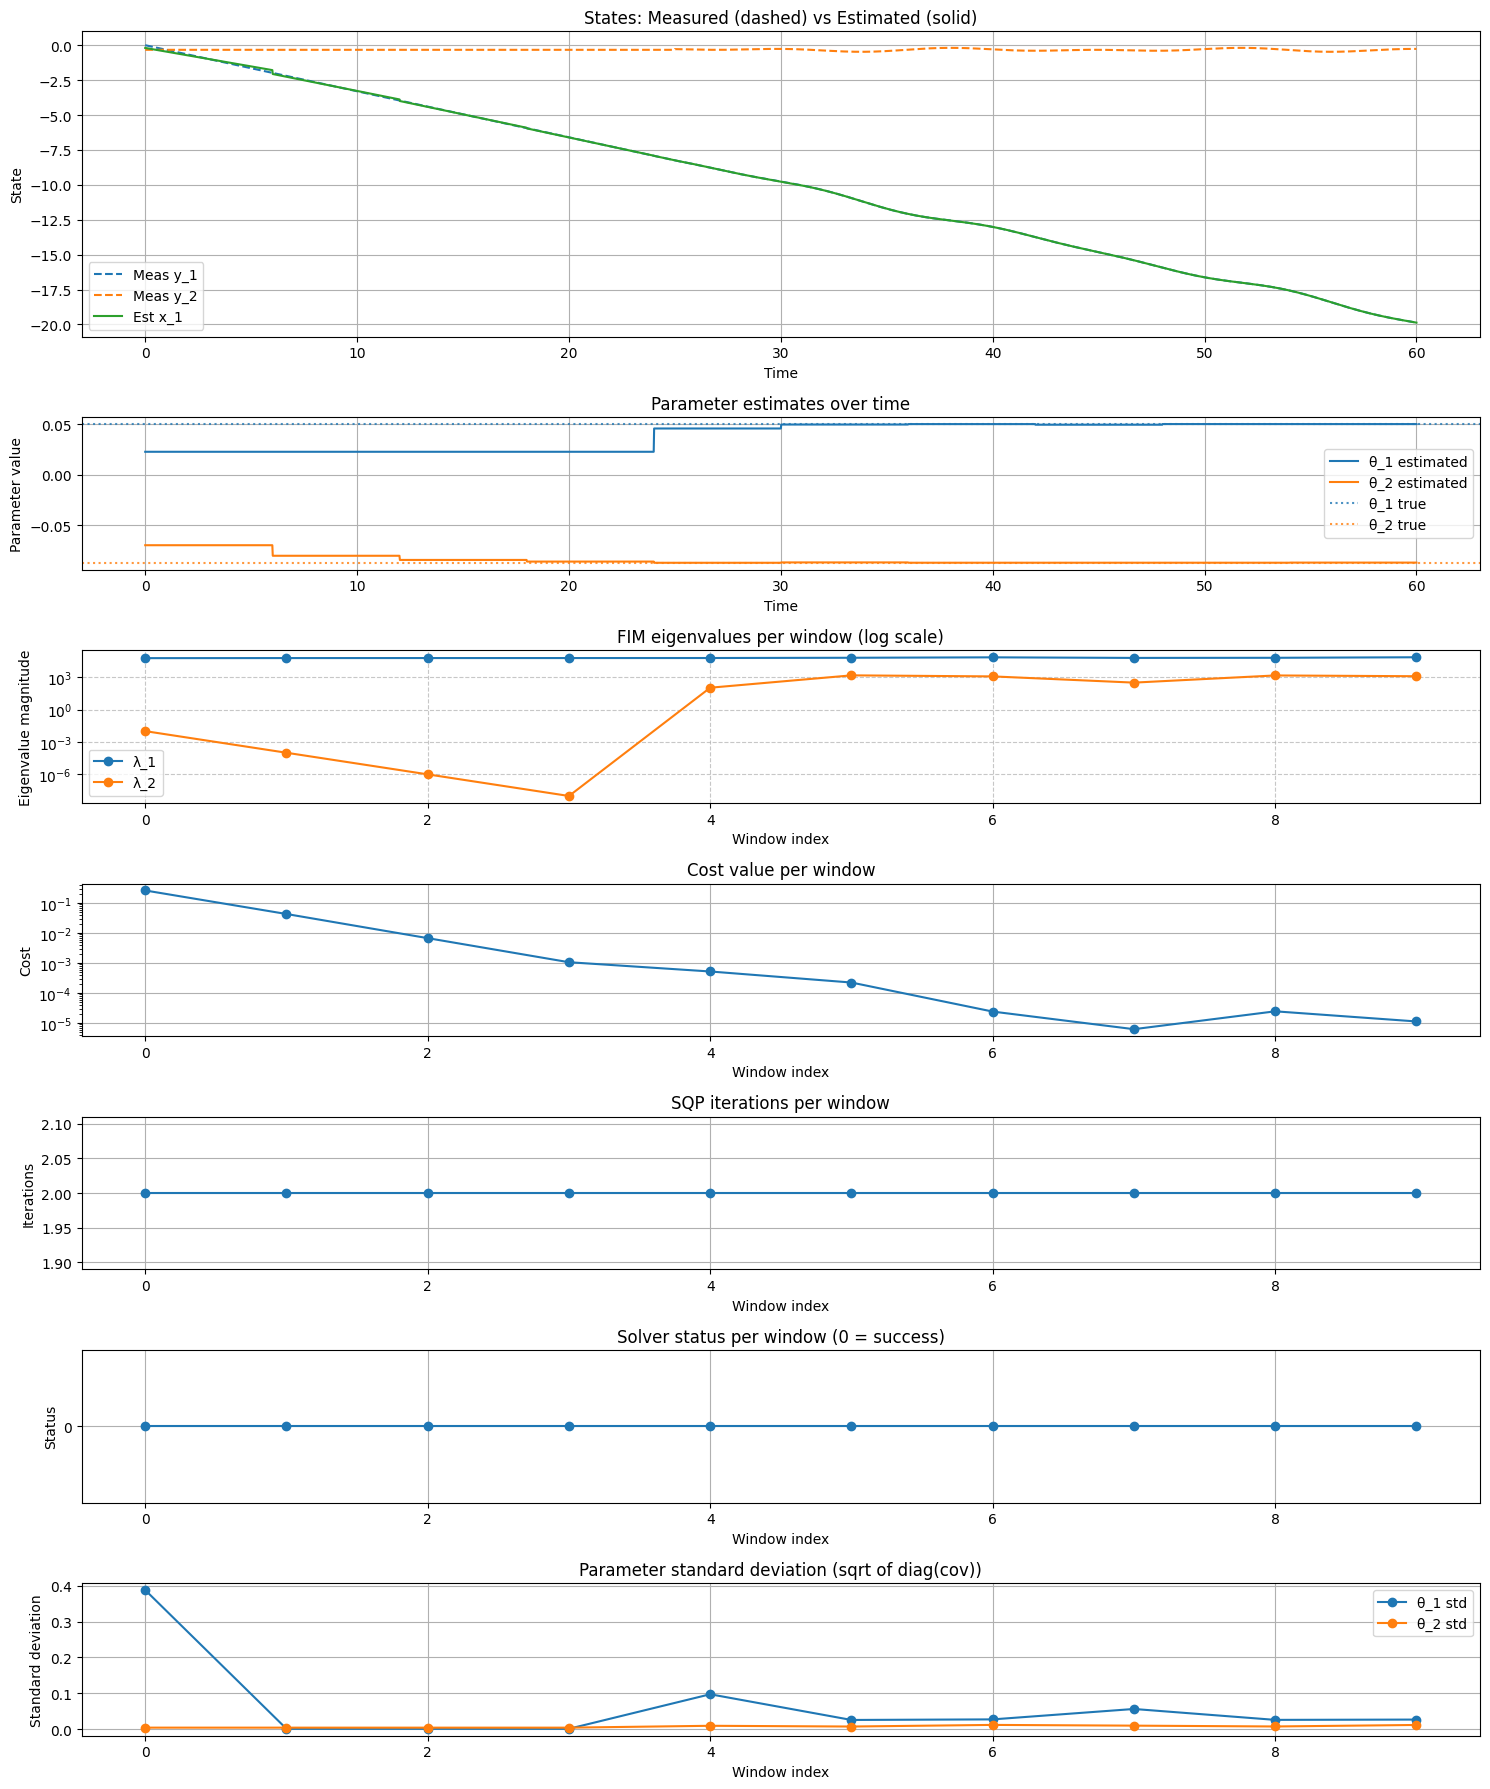

In [17]:
plot_mhe_results(results, overlap=overlap_points,
                 initial_params=None,
                 theta_true=theta_true,   # your true parameter array
                 plot_states=True,
                 plot_params=True,
                 plot_eigvals=True,
                 plot_noise=False,
                 plot_cost=True,
                 plot_iter=True,
                 plot_status=True,
                 figsize=(15, 18))   # slightly larger to accommodate taller first plot

In [10]:
initial_theta = theta_true
t_batch, simU, simY = get_window(10)
unknown_state_length = 0


initial_x0 = np.hstack((simY[0]))
print(initial_x0)
R_inv = np.diag(1*[1])
mhe_model=generator.get_model()
F = mhe_model.compute_fim(simY.shape[0], mhe_params.dt, simU, initial_x0, initial_theta, R_inv)
F
#set_mhe_solver(mhe_model, acados_solver_mhe, simY, simU, initial_x0, initial_theta, mhe_params.dt, N_measurement, unknown_state_length, R_inv)

[-1.23968548]


array([[ 1361.03263992,  8277.43431679],
       [ 8277.43431679, 52041.04294695]])

In [11]:
simU.shape

(501, 1)